# Investigating the structure factor 

In [2]:
import sys

sys.path.append("../../src")

import equilibrium_critical_correlations as eq

import kibble_zurek as kz

from common_imports import *

  0%|          | 0/200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
  0%|          | 0/200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 200/200 [00:06<00:00, 29.86it/s] 


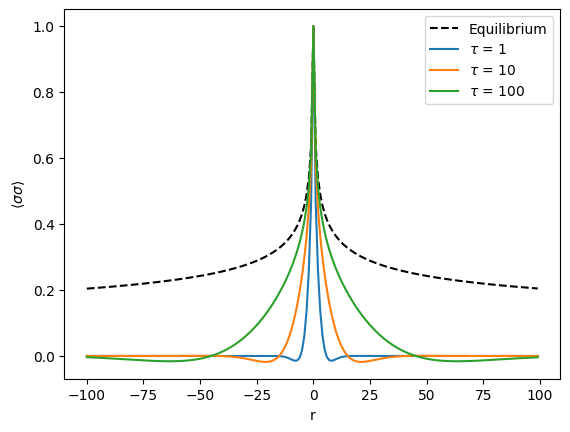

In [11]:
####
# Constants
####

taus = [1, 10 , 100] # three is enough for now

states = [kz.state(500,tau,0) for tau in taus] # L = 500 is enough, quench to g = 1

rs = np.arange(-100,100) #A wider range in R allows for more fidelity of structure factor

####
# 2 Point Functions
####

eq_xx = array([eq.sigma_general([0,r]) for r in tqdm(rs)]) #Equilibrium

quenched_xx = [ array([kz.sigma_general([0,r],s) for r in tqdm(rs)]) for s in states ]
plot(rs,eq_xx,"--k",label="Equilibrium")

for xx,tau in zip(quenched_xx,taus):
    plot(rs,xx,label=rf"$\tau$ = {tau}")

ylabel(r"$\langle \sigma \sigma \rangle$")
xlabel("r")
legend()

# Now let's Fourier Transform

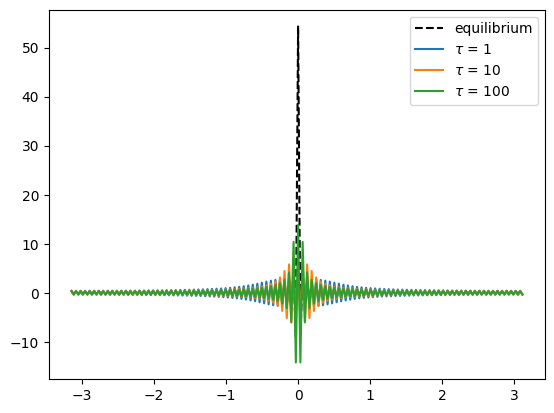

In [39]:
from numpy.fft import fft, fftfreq, fftshift
k = fftshift(fftfreq(len(rs),1))*2*pi
fourier_eq = fftshift(fft(eq_xx))
fourier_quenched = [fftshift(fft(xx)) for xx in quenched_xx]
plot(k,np.real(fourier_eq),"--k",label="equilibrium")
for xx,tau in zip(fourier_quenched, taus):
    plot(k, np.real(xx),label= rf"$\tau$ = {tau}")

legend()

In [52]:
from scipy.integrate import simpson

kmax = pi/100
dk = k[1] - k[0]
mask = np.abs(k) <= kmax

print(np.sum(fourier_eq[mask]) * dk / (2 * pi))

for xx in fourier_quenched:
    print(np.sum(xx[mask]) * dk / (2 * pi))


(0.1825203648856758+1.168219672362097e-18j)
(-0.013808628296264017+1.5528118924871342e-20j)
(-0.030382387754288954+3.124353837951785e-19j)
(-0.0729606331289288+2.9105860284467022e-19j)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_3881/90346995.py:19: RuntimeWarning: invalid value encountered in power
  plt.plot(k,3/4*k**(1/4))


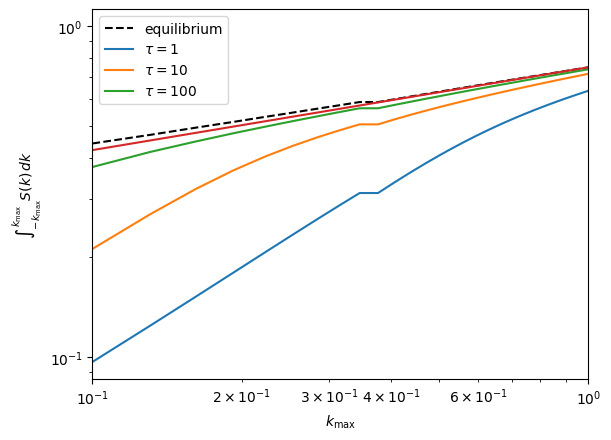

In [99]:
import numpy as np
import matplotlib.pyplot as plt

kmax_values = np.linspace(0.1, np.pi, 100)
dk = k[1] - k[0]

eq_vals = []
quenched_vals = [[] for _ in fourier_quenched]

for kmax in kmax_values:
    mask = np.abs(k) <= kmax
    eq_vals.append(np.sum(np.abs(fourier_eq[mask])) * dk / (2*np.pi))
    for i, xx in enumerate(fourier_quenched):
        quenched_vals[i].append(np.sum(np.abs(xx[mask])) * dk / (2*np.pi))

plt.plot(kmax_values, eq_vals, "--k", label="equilibrium")
for vals, tau in zip(quenched_vals, taus):
    plt.plot(kmax_values, vals, label=rf"$\tau={tau}$")
plt.plot(k,3/4*k**(1/4))
plt.xlabel(r"$k_{\max}$")
plt.ylabel(r"$\int_{-k_{\max}}^{k_{\max}} S(k)\,dk$")
loglog()
xlim(.1,1)
plt.legend()
plt.show()


0.5984652120629469 0.4796580927392202


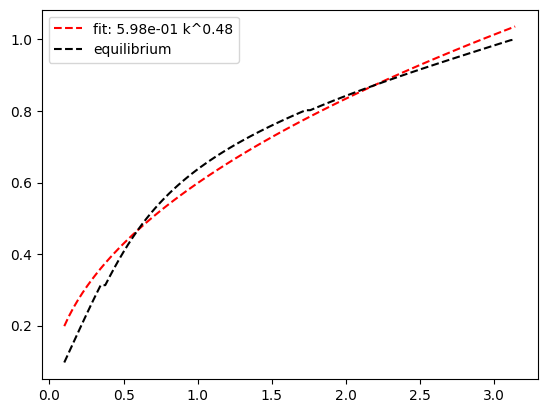

In [104]:
from scipy.optimize import curve_fit

def power(x, a, b):
    return a * x**b

popt, _ = curve_fit(power, kmax_values, quenched_vals[0])
a, b = popt
print(a, b)

plot(kmax_values, power(kmax_values, *popt), "--r", label=f"fit: {a:.2e} k^{b:.2f}")
plt.plot(kmax_values, quenched_vals[0], "--k", label="equilibrium")

legend()


(0.0, 1.0)

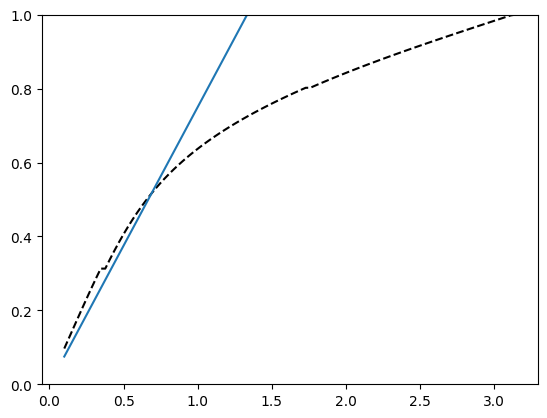

In [116]:
plt.plot(kmax_values, quenched_vals[0], "--k", label="equilibrium")
plt.plot(kmax_values,3/4*kmax_values**(1))
ylim(0,1)